# Credit Card Fraud Detection

## Objective

Predict whether a transaction is fraudulent based on various features of the transaction. This is a binary classification problem where the target variable is `Fraud`, indicating whether a transaction is fraudulent (1) or legitimate (0).

## Data Dictionary

1. **TransactionID**: Unique identifier for each transaction (integer).
2. **TransactionAmount**: Amount of the transaction in USD (float).
3. **TransactionTime**: Time of the transaction in hours since the first transaction (float).
4. **MerchantCategory**: Category of the merchant (categorical: 'Retail', 'Online', 'Restaurant', 'Travel').
5. **CustomerAge**: Age of the customer making the transaction (integer, ranging from 18 to 80).
6. **CustomerGender**: Gender of the customer (categorical: 'Male', 'Female').
7. **CustomerIncome**: Annual income of the customer in USD (integer, ranging from 20,000 to 200,000).
8. **TransactionLocation**: Location where the transaction took place (categorical: 'Urban', 'Suburban', 'Rural').
9. **PreviousFraudCount**: Number of fraudulent transactions by the customer in the past 6 months (integer, ranging from 0 to 5).
10. **Fraud**: Target variable indicating whether the transaction is fraudulent (1) or not (0) (binary).

    # Building a model using Logistic Regression

In [3]:
#import neccary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [7]:
#load the data fromset from file
df = pd.read_excel('fraud_dataset.xlsx')

In [8]:
#display first feww data
df.head()

,TransactionID,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount,Fraud
0,1,75.39,0.10,Retail,68,Female,190948,Urban,1,0
1,2,456.52,0.49,Retail,74,Female,127445,Urban,0,0
2,3,202.51,1.52,Travel,54,Female,40323,Suburban,0,0
3,4,141.94,2.18,Retail,25,Female,36428,Rural,0,0
4,5,30.44,3.00,Retail,24,Male,54578,Urban,0,0


In [9]:
#display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        1000 non-null   int64  
 1   TransactionAmount    1000 non-null   float64
 2   TransactionTime      1000 non-null   float64
 3   MerchantCategory     1000 non-null   object 
 4   CustomerAge          1000 non-null   int64  
 5   CustomerGender       1000 non-null   object 
 6   CustomerIncome       1000 non-null   int64  
 7   TransactionLocation  1000 non-null   object 
 8   PreviousFraudCount   1000 non-null   int64  
 9   Fraud                1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


In [10]:
#summary statistics
df.describe()

,TransactionID,TransactionAmount,TransactionTime,CustomerAge,CustomerIncome,PreviousFraudCount,Fraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,150.875730,266.601600,49.562000,110182.030000,0.556000,0.075000
std,288.819436,145.876565,147.575418,18.513803,52101.038452,1.022697,0.263523
min,1.000000,5.700000,0.100000,18.000000,20066.000000,0.000000,0.000000
25%,250.750000,45.375000,146.010000,34.000000,66192.250000,0.000000,0.000000
50%,500.500000,108.020000,270.280000,49.000000,110105.500000,0.000000,0.000000
75%,750.250000,209.577500,393.885000,66.000000,156281.500000,1.000000,0.000000
max,1000.000000,1230.870000,517.560000,80.000000,199971.000000,5.000000,1.000000


In [12]:
#check for any null values
df.isnull().sum()

TransactionID          0
TransactionAmount      0
TransactionTime        0
MerchantCategory       0
CustomerAge            0
CustomerGender         0
CustomerIncome         0
TransactionLocation    0
PreviousFraudCount     0
Fraud                  0
dtype: int64

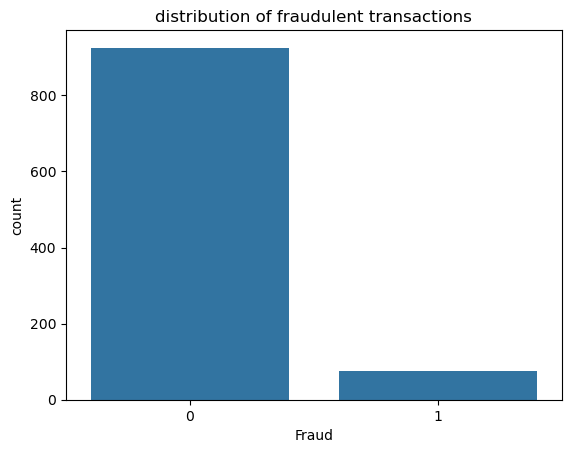

In [13]:
#distribution of target varibel

sns.countplot(x='Fraud',data=df)
plt.title('distribution of fraudulent transactions')
plt.show()

## case of imbalanced dataset

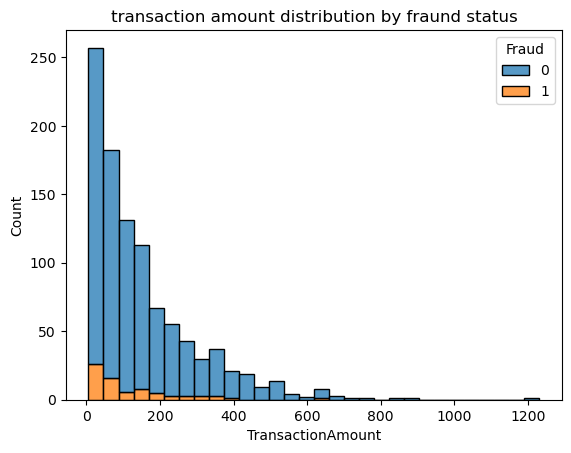

In [15]:
#distribution of transaction amount by fraud status

sns.histplot(data=df,x='TransactionAmount',hue='Fraud',multiple='stack',bins=30)
#x = 'TransactionAmount' → Data on x-axis
#hue = 'Fraud' → Separate by Fraud column
#multiple='stack' → Stack them together , as you can see the graph of two categories fraud and not fruad are overlayed over each other 
#Different colors for Fraud = 0 and Fraud = 1
plt.title('transaction amount distribution by fraund status')
plt.show()

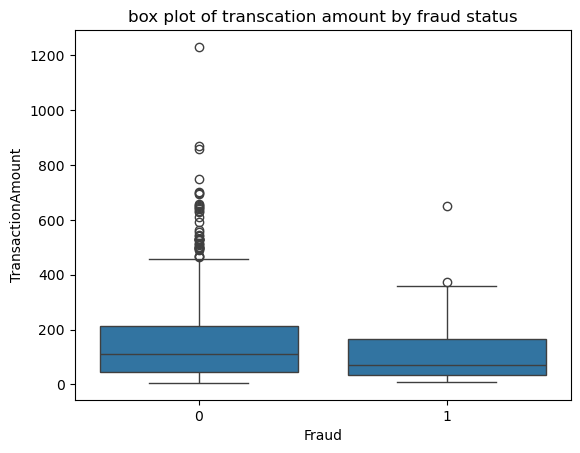

In [17]:
#box plot for transation amount by fraud status

sns.boxplot(x='Fraud',y='TransactionAmount',data=df)
plt.title('box plot of transcation amount by fraud status')
plt.show()

## The way one wrote this code is actually very clever for a "Real World" dataset:

code

### num_cols = list()
### for column in df.columns:
###   if df[column].dtype != object:
###        num_cols.append(column)
Why you did this: Correlation math only works on numbers. Since your dataset has "Objects" (strings like 'Male', 'Female', 'Retail'), trying to run .corr() on the whole dataframe would usually cause an error or skip those columns. Your loop acts as a filter to ensure only the numeric columns (Age, Income, Amount, etc.) are sent to the heatmap     

1.
For each column:
        if df[column].dtype != object:
Checks if the column is not text/string.

2.
num_cols.append(column)
Adds numeric columns to the list. example TransactionAmount,TransactionTime etc

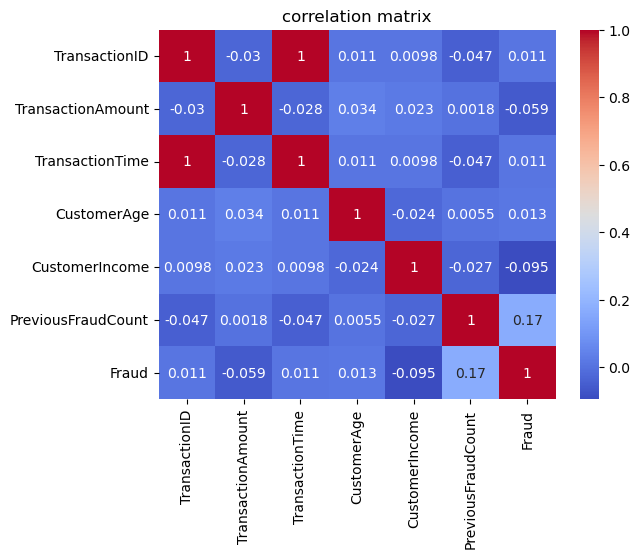

In [18]:
#correaltion matrix

num_cols= list()

for column in df.columns:
    if df[column].dtype!=object:
        num_cols.append(column)

correlation_matrix=df[num_cols].corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

## Data Preprocessing

In [21]:
# Encode categorical variables
label_encoders = {} #Creates an empty dictionary
                    #Used to store encoders for each column
for column in ['MerchantCategory', 'CustomerGender', 'TransactionLocation']:
    le = LabelEncoder() # helps in creating an instance of "le" to encode this variables 
    df[column] = le.fit_transform(df[column])
#This:Learns categories
#This converts text → numbers
#Example:
#Before:                   || #After:
#Retail, Online, Travel    || #0, 1, 2
    label_encoders[column] = le

# Features and target
X = df.drop(['TransactionID', 'Fraud'], axis=1)# transactionId value is not required beacuse all the values are unique in this case so wont be in the need of transcationid
                                               # and fraud is the output column so we need to use it in y axis
y = df['Fraud']


In [22]:
X.head()

,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount
0,75.39,0.10,2,68,0,190948,2,1
1,456.52,0.49,2,74,0,127445,2,0
2,202.51,1.52,3,54,0,40323,1,0
3,141.94,2.18,2,25,0,36428,0,0
4,30.44,3.00,2,24,1,54578,2,0


In [23]:
#split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
#Feature scaling
#Feature Scaling — making all values in your dataset on the same scale
scaler=StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


In [28]:
#logistic regression

from sklearn.linear_model import LogisticRegression

logreg=LogisticRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
# Uses trained model
# Predicts values for test data
# Example output: [0,1,0,0,1,0]
# 0 → Not Fraud
# 1 → Fraud

logreg_accuracy = accuracy_score(y_test, logreg_pred)
# Calculate model accuracy
# Accuracy = Correct Predictions / Total Predictions
# Example:
# Correct = 80
# Total = 100
# Accuracy = 80%

In [29]:
# Display accuracy and performance metrics

accuracy_percent = logreg_accuracy * 100
# Show model accuracy in percentage
# logreg_accuracy * 100 converts it into %
print("Logistic Regression Accuracy:", accuracy_percent, "%")

print('\nLogistic Regression Classification Report:')
# Print detailed performance report of model
# It shows:
# - Precision
# - Recall
# - F1-score
# - Support
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 90.0 %

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       180
           1       0.00      0.00      0.00        20

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.81      0.90      0.85       200

